In [11]:
%reload_ext autoreload
%autoreload 2

In [13]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from flax import nnx
from probjax.nn import MLP

X = np.linspace(0, 1, 100)[:, None]
Y = 0.8 * X**2 + 0.1 + np.random.normal(0, 0.1, size=X.shape)

def dataset(batch_size):
  while True:
    idx = np.random.choice(len(X), size=batch_size)
    yield X[idx], Y[idx]




In [14]:
model = MLP([1,50,50,1], rngs=nnx.Rngs(0))
nnx.display(model)

In [4]:
nnx.initializers.orthogonal()(nnx.Rngs(0).next(), (2,2))

Array([[ 0.911,  0.412],
       [ 0.412, -0.911]], dtype=float32)

In [5]:
def logdenstiy_fn(model):
    y = model(X)
    return -0.5*jnp.sum((Y - y)**2)/0.5**2 - jax.tree_util.tree_reduce(lambda x, y: jnp.sum(y**2) + jnp.sum(y**2), model) # With prior


In [19]:
jax.jit(logdenstiy_fn)(model)

Array(-6.022, dtype=float32)

In [20]:
from probjax.inference.kernels import HMC
from probjax.inference.mcmc import MCMC
import jax

kernel = HMC(logdenstiy_fn)

state = kernel.init(model)
params = kernel.init_params(model, step_size=5e-4)

In [21]:
mcmc = MCMC(kernel, verbose=True)

In [22]:
state = mcmc.run(jax.random.PRNGKey(0), state, 5_000, params)

(-3.0, 3.0)

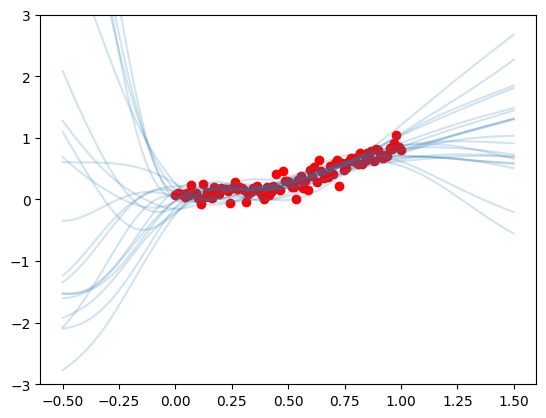

In [23]:
plt.scatter(X, Y, color="red")
for i in range(20):
    state = mcmc.run(jax.random.PRNGKey(i), state, 500, params=params)
    model = state.position
    x = np.linspace(-0.5, 1.5, 100)[:, None]
    plt.plot(x, model(x), color='C0', alpha=0.2)

plt.ylim(-3., 3.)
